# Clustering Community and Compositional Data in R

## Overview

Cluster analysis groups sites (or samples) by compositional similarity without reference to predetermined groups. Combined with ordination (NMDS, PCA), it helps reveal natural groupings in community data and identify site types for further analysis.

| Method | Type | Distance Input | Use Case |
|---|---|---|---|
| **Hierarchical clustering** | Agglomerative | Any distance matrix | Discovering hierarchical groupings; dendrogram visualization |
| **k-means** | Partitional | Euclidean (on transformed data) | Partitioning into k groups when k is known or tested |
| **PAM** (k-medoids) | Partitional | Any distance matrix | More robust to outliers than k-means; works with any distance |

**Linkage methods for hierarchical clustering:**

| Method | Behaviour | When to Use |
|---|---|---|
| Average (UPGMA) | Joins groups by average pairwise distance | General purpose; commonly used for community data |
| Ward's D2 | Minimizes within-cluster variance | When compact, equal-sized clusters are expected |
| Complete | Joins by maximum pairwise distance | Compact clusters; sensitive to outliers |
| Single | Joins by minimum pairwise distance | Chain-forming; rarely appropriate for ecology |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)
library(cluster)       # pam(), silhouette()
library(factoextra)    # fviz_dend(), fviz_silhouette(), fviz_nbclust()
library(dendextend)    # color_branches(), colored_bars()
library(patchwork)

set.seed(42)

# ── Community matrix ──────────────────────────────────────────────────────────
n_sites <- 45; n_sp <- 20
habitat <- rep(c("reference", "degraded", "restored"), each = 15)

ref_means  <- c(8,7,6,5,5,4,3,3,2,2,1,1,0,0,0,0,0,0,0,0)
deg_means  <- c(0,0,1,1,2,3,4,5,6,7,8,6,4,2,1,1,0,0,0,0)
rest_means <- c(4,4,4,3,3,3,3,2,2,2,2,2,1,1,1,0,0,0,0,0)

sim_comm <- function(n, mu, sd = 0.7)
  t(replicate(n, pmax(round(exp(rnorm(n_sp, log(mu + 0.1), sd))), 0L)))

comm_mat <- rbind(sim_comm(15, ref_means),
                  sim_comm(15, deg_means),
                  sim_comm(15, rest_means))
rownames(comm_mat) <- paste0("site", 1:n_sites)
colnames(comm_mat) <- paste0("sp",   1:n_sp)

dist_bray <- vegan::vegdist(comm_mat, method = "bray")
hab_factor <- factor(habitat, levels = c("reference", "degraded", "restored"))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute

Welcome! Want to learn more? Se

---

## Hierarchical Clustering

Cophenetic correlation: average=0.830  ward=0.790


                   habitat
cluster_assignments degraded reference restored
                  1        0        14       15
                  2        1         1        0
                  3       14         0        0

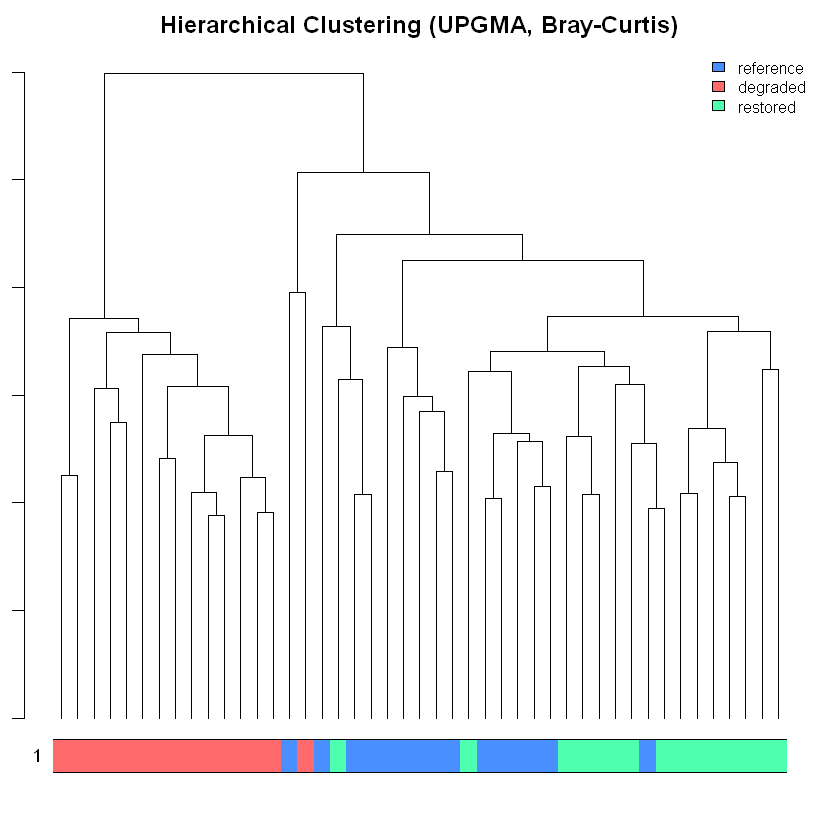

In [2]:
# ── Fit hierarchical clustering with average linkage ─────────────────────────
hc_avg <- hclust(dist_bray, method = "average")   # UPGMA
hc_ward <- hclust(dist_bray, method = "ward.D2")

# ── Cophenetic correlation: how well does the dendrogram represent distances? ─
coph_avg  <- cor(dist_bray, cophenetic(hc_avg))
coph_ward <- cor(dist_bray, cophenetic(hc_ward))
cat(sprintf("Cophenetic correlation: average=%.3f  ward=%.3f\n",
            coph_avg, coph_ward))
# Higher = dendrogram better represents original distances (0-1 scale)
# Average linkage typically has higher cophenetic correlation

# ── Dendrogram with habitat color bars ───────────────────────────────────────
dend <- as.dendrogram(hc_avg)
hab_colors <- c(reference = "#4a8fff", degraded = "#ff6b6b", restored = "#4fffb0")
bar_colors <- hab_colors[habitat[order.dendrogram(dend)]]

par(mar = c(4, 1, 2, 1))
plot(dend, main = "Hierarchical Clustering (UPGMA, Bray-Curtis)",
     leaflab = "none", ylab = "Bray-Curtis Distance")
colored_bars(bar_colors, dend, sort_by_labels_order = FALSE,
             y_scale = 0.03, y_shift = -0.02)
legend("topright", legend = names(hab_colors),
       fill = hab_colors, bty = "n", cex = 0.8)

# ── Cut dendrogram into k groups ──────────────────────────────────────────────
k <- 3
cluster_assignments <- cutree(hc_avg, k = k)

# Compare cluster assignments with known habitat groups
table(cluster_assignments, habitat)

---

## Choosing the Number of Clusters

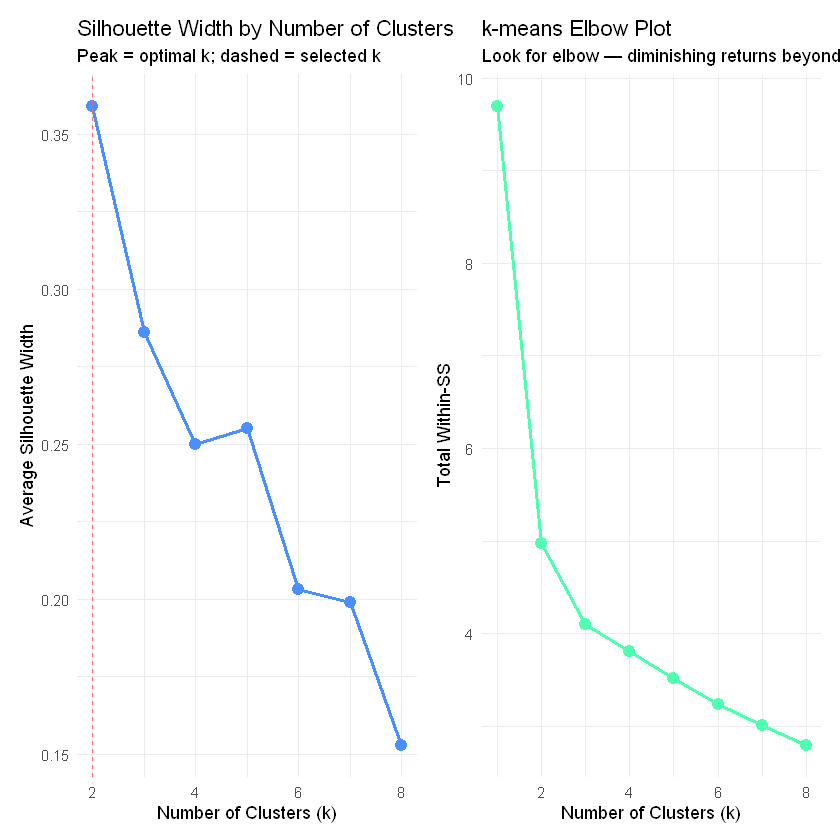

In [3]:
# ── 1. Silhouette width ───────────────────────────────────────────────────────
# Average silhouette width: how well each site fits its assigned cluster
# Values range -1 to 1; higher = better-defined clusters
sil_widths <- map_dbl(2:8, function(k) {
  cuts  <- cutree(hc_avg, k = k)
  sil   <- silhouette(cuts, dist_bray)
  mean(sil[, "sil_width"])
})

sil_df <- tibble(k = 2:8, avg_silhouette = sil_widths)

p_sil <- ggplot(sil_df, aes(x = k, y = avg_silhouette)) +
  geom_line(color = "#4a8fff", linewidth = 1) +
  geom_point(size = 3, color = "#4a8fff") +
  geom_vline(xintercept = which.max(sil_widths) + 1,
             linetype = "dashed", color = "#ff6b6b") +
  labs(title = "Silhouette Width by Number of Clusters",
       subtitle = "Peak = optimal k; dashed = selected k",
       x = "Number of Clusters (k)",
       y = "Average Silhouette Width") +
  theme_minimal()

# ── 2. Elbow plot (total within-cluster SS) for k-means ──────────────────────
# Requires Hellinger-transformed data (Euclidean-compatible)
comm_hell <- vegan::decostand(comm_mat, method = "hellinger")

wss <- map_dbl(1:8, function(k) {
  kmeans(comm_hell, centers = k, nstart = 25)$tot.withinss
})

p_elbow <- ggplot(tibble(k=1:8, wss=wss), aes(x=k, y=wss)) +
  geom_line(color="#4fffb0", linewidth=1) +
  geom_point(size=3, color="#4fffb0") +
  labs(title="k-means Elbow Plot",
       subtitle="Look for elbow — diminishing returns beyond optimal k",
       x="Number of Clusters (k)", y="Total Within-SS") +
  theme_minimal()

(p_sil | p_elbow)

---

## PAM (k-Medoids): Robust Partitional Clustering

PAM works directly on the distance matrix and is more robust to outliers than k-means. The medoid of each cluster is an actual site (not an abstract centroid), making results more interpretable.

Optimal k: 2
Medoid sites (representative of each cluster):
[1] NA NA


Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


  cluster size ave.sil.width
1       1   31          0.32
2       2   14          0.45


           Habitat
PAM_cluster degraded reference restored
          1        1        15       15
          2       14         0        0

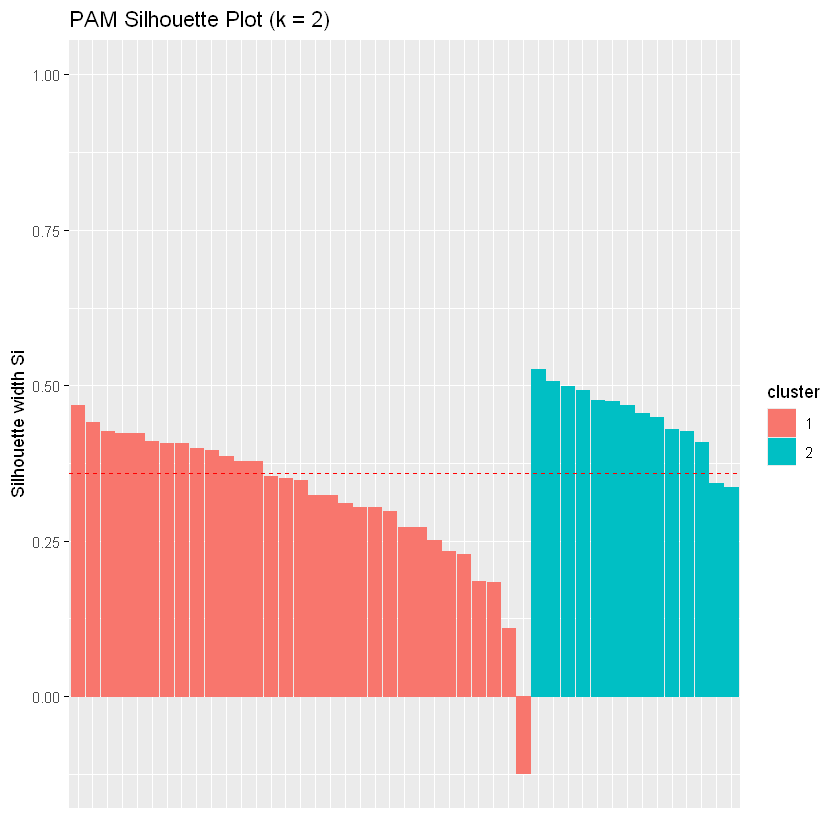

In [4]:
# ── Fit PAM ───────────────────────────────────────────────────────────────────
k_opt <- which.max(sil_widths) + 1   # optimal k from silhouette
pam_result <- cluster::pam(dist_bray, k = k_opt)

cat(sprintf("Optimal k: %d\n", k_opt))
cat("Medoid sites (representative of each cluster):\n")
print(rownames(comm_mat)[pam_result$medoids])

# ── Silhouette plot for PAM ───────────────────────────────────────────────────
sil_pam <- silhouette(pam_result)
factoextra::fviz_silhouette(sil_pam) +
  labs(title = sprintf("PAM Silhouette Plot (k = %d)", k_opt))
# Each bar = one site; positive = well-classified; negative = misclassified
# Average width shown as dashed line

# ── Compare PAM clusters with habitat labels ──────────────────────────────────
table(PAM_cluster = pam_result$clustering, Habitat = habitat)

---

## Overlay Clusters on NMDS

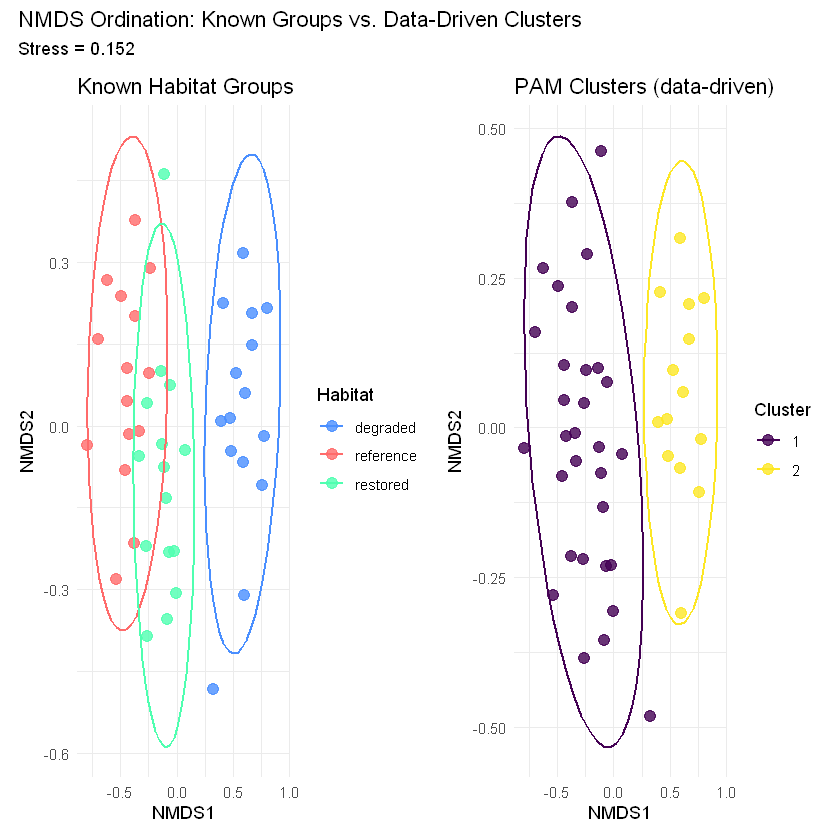

In [5]:
nmds <- vegan::metaMDS(dist_bray, k=2, trymax=100, trace=0)

nmds_df <- as.data.frame(vegan::scores(nmds, display="sites")) %>%
  rownames_to_column("site") %>%
  mutate(
    habitat     = habitat,
    pam_cluster = factor(pam_result$clustering),
    hc_cluster  = factor(cutree(hc_avg, k = k_opt))
  )

p_hab <- ggplot(nmds_df, aes(x=NMDS1, y=NMDS2, color=habitat)) +
  geom_point(size=3, alpha=0.8) +
  stat_ellipse(level=0.95, linewidth=0.7) +
  scale_color_manual(values=c("#4a8fff","#ff6b6b","#4fffb0")) +
  labs(title="Known Habitat Groups", color="Habitat") +
  theme_minimal()

p_pam <- ggplot(nmds_df, aes(x=NMDS1, y=NMDS2, color=pam_cluster)) +
  geom_point(size=3, alpha=0.8) +
  stat_ellipse(level=0.95, linewidth=0.7) +
  scale_color_viridis_d() +
  labs(title="PAM Clusters (data-driven)", color="Cluster") +
  theme_minimal()

(p_hab | p_pam) +
  patchwork::plot_annotation(
    title    = "NMDS Ordination: Known Groups vs. Data-Driven Clusters",
    subtitle = sprintf("Stress = %.3f", nmds$stress)
  )

---

## Common Pitfalls

**1. Applying k-means directly to species count matrices**  
k-means minimizes Euclidean distance, which is inappropriate for raw species counts (double-zero problem, scale sensitivity). Always Hellinger-transform first, or use PAM with Bray-Curtis distance instead.

**2. Choosing k arbitrarily or based on prior knowledge alone**  
Always evaluate multiple k values using silhouette width or the elbow method, even when you have prior knowledge about the number of groups. The data may not support the expected number of clusters.

**3. Using single linkage**  
Single linkage clustering creates chains — sites join the nearest cluster member, producing long, stringy, uninterpretable clusters. Almost never appropriate for community data. Use average linkage (UPGMA) or Ward's D2.

**4. Presenting clusters without silhouette assessment**  
Clusters always emerge from hierarchical or k-means algorithms — they will appear even when no real grouping exists. Always report average silhouette width as a measure of cluster quality. Low silhouette (< 0.25) suggests weak or absent structure.

**5. Treating cluster assignments as ground truth**  
Clusters are a useful heuristic for summarizing community structure, not definitive group memberships. Sites with negative silhouette values are genuinely ambiguous — acknowledge this rather than forcing them into a group.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*